# Sparse Gaussian Process Emulator for Heston Implied Volatility

This notebook trains a **sparse** Gaussian Process (GP) emulator for Heston implied volatility using the simulated option surface data.

An exact GP has to invert the dense $N \times N$ covariance matrix, which costs $\mathcal{O}(N^3)$ time and $\mathcal{O}(N^2)$ memory. The exact-GP notebook keeps this affordable by capping the training set at `MAX_GP_TRAIN_ROWS`. Here we remove that cap: a **variational sparse GP** (Titsias, 2009 - also called *SGPR*) summarises **all** training rows with a small set of $M$ inducing points, reducing the cost to $\mathcal{O}(N M^2)$ so the emulator can learn from the full training split.

Workflow:
1. Load `data/simulated_training_data.csv`.
2. Split rows into train and validation sets.
3. Standardize the input features so Heston parameters, strikes, and maturities live on comparable scales.
4. Place $M$ inducing points with k-means and fit a sparse GP (SGPR) on **all** training rows using an RBF kernel and a white-noise term.
5. Validate predictions with error metrics and a predicted-vs-true implied volatility plot.


In [1]:
from pathlib import Path
import os
import tempfile

# Keep Matplotlib cache files out of the project and user home directory.
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "hestongp_matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "hestongp_matplotlib_cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import cholesky, solve_triangular
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
DATA_PATH = Path("data/simulated_training_data.csv")
OUTPUT_DIR = Path("outputs/sparse_gp_emulator_sklearn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho", "K", "T"]
TARGET_COLUMN = "implied_vol"

RANDOM_STATE = 42
VALIDATION_SIZE = 0.20

# Sparse GP: summarise all N training rows with M << N inducing points, so the
# cost is O(N M^2) instead of the O(N^3) of an exact GP and no row cap is needed.
NUM_INDUCING = 2500
# Small diagonal added to K(Z, Z) to keep its Cholesky factorisation stable.
JITTER = 1e-6


In [3]:
df = pd.read_csv(DATA_PATH)

required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Keep only the columns needed for this emulator and remove invalid rows.
df = df[required_columns].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Loaded {len(df):,} clean rows")
df.head()


Loaded 51,867 clean rows


,v0,kappa,theta,sigma_v,rho,K,T,implied_vol
0,0.074996,2.1533,0.187783,0.297192,-0.273026,85.0,0.019178,0.291981
1,0.074996,2.1533,0.187783,0.297192,-0.273026,90.0,0.019178,0.286550
2,0.074996,2.1533,0.187783,0.297192,-0.273026,95.0,0.019178,0.281765
3,0.074996,2.1533,0.187783,0.297192,-0.273026,100.0,0.019178,0.277771
4,0.074996,2.1533,0.187783,0.297192,-0.273026,105.0,0.019178,0.274608


In [4]:
X = df[FEATURE_COLUMNS].to_numpy(dtype=float)
y = df[TARGET_COLUMN].to_numpy(dtype=float)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")


Training rows:   41,493
Validation rows: 10,374


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Check that the scaled training inputs are centered and comparable in scale.
scaled_summary = pd.DataFrame(
    {
        "mean": X_train_scaled.mean(axis=0),
        "std": X_train_scaled.std(axis=0),
    },
    index=FEATURE_COLUMNS,
)
scaled_summary


,mean,std
v0,2.006806e-14,1.0
kappa,-1.385342e-14,1.0
theta,-6.790595e-15,1.0
sigma_v,2.533065e-14,1.0
rho,-2.552308e-14,1.0
K,-1.125726e-15,1.0
T,-2.130599e-13,1.0


## Inducing points

A sparse GP represents the full training set through $M$ *inducing inputs* $Z = \{z_1, \dots, z_M\}$ that act as a compact summary of where the function is "anchored". Rather than picking them at random, we place them at **k-means cluster centres** of the (standardised) training inputs, so they spread out to cover the input space the emulator will be queried over. Unlike the exact-GP notebook, every training row is kept: the inducing points, not a row cap, are what control the cost.


In [6]:
# Place the inducing points at k-means centres of the full scaled training set.
kmeans = KMeans(n_clusters=NUM_INDUCING, random_state=RANDOM_STATE, n_init="auto")
kmeans.fit(X_train_scaled)
Z = kmeans.cluster_centers_  # (M, d) inducing inputs

# Train the sparse GP on every training row (no MAX_* cap).
X_sparse_gp_train = X_train_scaled

# Standardise the target, mirroring normalize_y=True in the exact-GP notebook.
y_train_mean = y_train.mean()
y_train_std = y_train.std()
y_sparse_gp_train = (y_train - y_train_mean) / y_train_std

print(f"Rows used for sparse GP fit: {len(X_sparse_gp_train):,}")
print(f"Inducing points:             {len(Z):,}")


Rows used for sparse GP fit: 41,493
Inducing points:             2,500


## Fitting the sparse GP

We fit the sparse emulator using the variational inducing-point method of Titsias (2009). The full training set is represented through a smaller set of inducing points, which reduces the cost of GP training while retaining information from all training examples.

The inducing locations are selected using `KMeans` on the standardized training inputs. With these locations fixed, the code optimizes the anisotropic RBF length scales and observation-noise level by maximizing the variational lower bound, implemented as minimization of the negative ELBO with `scipy.optimize.minimize` and the L-BFGS-B algorithm.

The required covariance calculations are performed using Cholesky factorizations and triangular solves through `scipy.linalg.cholesky` and `solve_triangular`. This avoids explicitly constructing or inverting the full training covariance matrix. The fitted quantities are then used to compute the predictive mean and standard deviation for new inputs.

The variational formulation follows Titsias (2009) [https://proceedings.mlr.press/v5/titsias09a/titsias09a.pdf].

In [7]:
d = len(FEATURE_COLUMNS)
I_M = np.eye(NUM_INDUCING)


def _sparse_gp_factors(theta):
    """Cholesky factors and weight vector shared by the ELBO and the predictor.

    theta packs the log RBF length-scales (first d entries) and the log noise
    variance (last entry).
    """
    kernel = RBF(length_scale=np.exp(theta[:d]))
    noise = np.exp(theta[d])
    sigma = np.sqrt(noise)

    Kmm = kernel(Z) + JITTER * I_M          # (M, M)
    Kmn = kernel(Z, X_sparse_gp_train)      # (M, N)
    L = cholesky(Kmm, lower=True)           # Kmm = L L^T
    A = solve_triangular(L, Kmn, lower=True) / sigma   # (M, N)
    B = A @ A.T + I_M                        # (M, M)
    LB = cholesky(B, lower=True)             # B = LB LB^T
    c = solve_triangular(LB, A @ y_sparse_gp_train, lower=True) / sigma  # (M,)
    return kernel, L, LB, c, A, noise


def negative_elbo(theta):
    """Negative Titsias variational bound (the objective we minimise)."""
    _, _, LB, c, A, noise = _sparse_gp_factors(theta)
    n = len(y_sparse_gp_train)
    # trace(K_nn) = n because the unit-amplitude RBF has k(x, x) = 1.
    bound = -0.5 * n * np.log(2 * np.pi)
    bound -= np.sum(np.log(np.diag(LB)))
    bound -= 0.5 * n * np.log(noise)
    bound -= 0.5 * (y_sparse_gp_train @ y_sparse_gp_train) / noise
    bound += 0.5 * (c @ c)
    bound -= 0.5 * n / noise
    bound += 0.5 * np.trace(A @ A.T)
    return -bound


# Optimise the length-scales and noise; start from length_scale=1, noise=1e-4.
theta0 = np.concatenate([np.zeros(d), [np.log(1e-4)]])
result = minimize(negative_elbo, theta0, method="L-BFGS-B")

# Cache the fitted kernel and factors for prediction.
sparse_gp_kernel, sparse_gp_L, sparse_gp_LB, sparse_gp_c, _, sparse_gp_noise = _sparse_gp_factors(result.x)
sparse_gp_length_scale = np.exp(result.x[:d])

print("Learned RBF length scales:", np.round(sparse_gp_length_scale, 3))
print(f"Learned noise level: {sparse_gp_noise:.3e}")


Learned RBF length scales: [1.199 6.449 7.838 4.826 4.1   1.411 1.936]
Learned noise level: 2.544e-04


In [8]:
def sparse_gp_predict(X_star):
    """Posterior mean and standard deviation of the sparse GP at X_star."""
    Kms = sparse_gp_kernel(Z, X_star)                        # (M, Nt)
    w = solve_triangular(sparse_gp_L, Kms, lower=True)       # (M, Nt)
    v = solve_triangular(sparse_gp_LB, w, lower=True)        # (M, Nt)

    mean = v.T @ sparse_gp_c
    # Latent variance; Kss diag = 1 for the unit-amplitude RBF.
    var = 1.0 - np.sum(w ** 2, axis=0) + np.sum(v ** 2, axis=0)

    # Undo the target standardisation applied before fitting.
    mean = mean * y_train_std + y_train_mean
    std = np.sqrt(np.clip(var, 0.0, None)) * y_train_std
    return mean, std


y_pred, y_std = sparse_gp_predict(X_val_scaled)

mae = mean_absolute_error(y_val, y_pred)
rmse = mean_squared_error(y_val, y_pred) ** 0.5
r2 = r2_score(y_val, y_pred)
max_abs_error = np.max(np.abs(y_pred - y_val))

metrics = pd.Series(
    {
        "mean_absolute_error": mae,
        "root_mean_squared_error": rmse,
        "max_absolute_error": max_abs_error,
        "r2": r2,
        "train_rows": len(X_train),
        "validation_rows": len(X_val),
        "inducing_points": NUM_INDUCING,
    }
)
metrics


mean_absolute_error            0.000537
root_mean_squared_error        0.001157
max_absolute_error             0.025681
r2                             0.999844
train_rows                 41493.000000
validation_rows            10374.000000
inducing_points             2500.000000
dtype: float64

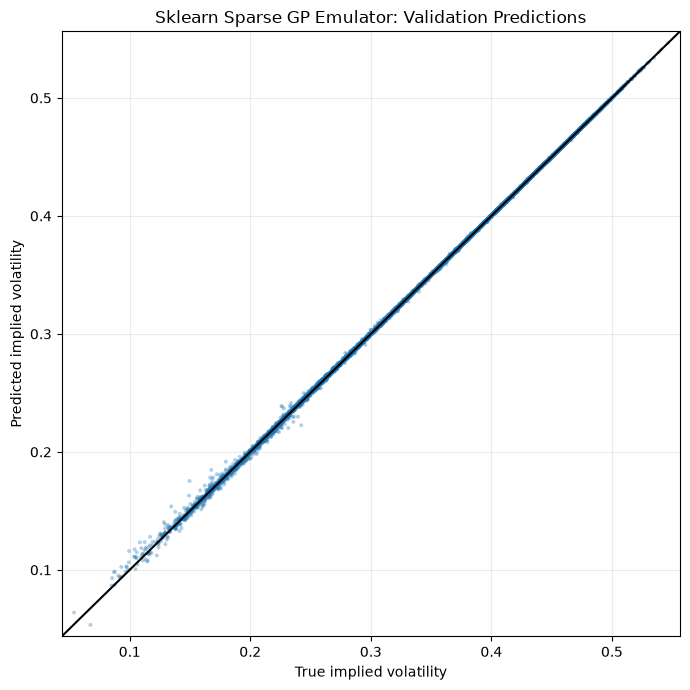

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_val, y_pred, s=8, alpha=0.35, edgecolors="none")

low = min(y_val.min(), y_pred.min())
high = max(y_val.max(), y_pred.max())
pad = 0.02 * (high - low)
ax.plot([low - pad, high + pad], [low - pad, high + pad], color="black", lw=1.5)

ax.set_xlabel("True implied volatility")
ax.set_ylabel("Predicted implied volatility")
ax.set_title("Sklearn Sparse GP Emulator: Validation Predictions")
ax.set_xlim(low - pad, high + pad)
ax.set_ylim(low - pad, high + pad)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


In [10]:
validation_results = pd.DataFrame(
    {
        "true_implied_vol": y_val,
        "predicted_implied_vol": y_pred,
        "predictive_std": y_std,
        "absolute_error": np.abs(y_pred - y_val),
    }
)

validation_results.to_csv(OUTPUT_DIR / "sparse_gp_validation_predictions.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "sparse_gp_validation_metrics.csv", header=["value"])
fig.savefig(OUTPUT_DIR / "sparse_gp_predicted_vs_true_iv.png", dpi=180)

print(f"Saved validation artifacts to {OUTPUT_DIR}")


Saved validation artifacts to outputs/sparse_gp_emulator_sklearn


## Export the model for calibration

The sparse GP posterior mean is $\mu_* = k(X_*, Z)\,\beta$ with $\beta = L^{-\top} L_B^{-\top} c$. This is the same $k(X_*, \cdot)\,\alpha$ form as an exact GP, but with the $M$ inducing points $Z$ standing in for the training set and unit signal variance. We save it in that shared layout so the calibration notebook can load it with the existing emulator loader.

In [11]:
# Collapse the two solves into a single weight vector beta = L^{-T} L_B^{-T} c,
# so prediction becomes k(X*, Z) @ beta (the exact-GP alpha form).
sparse_gp_beta = solve_triangular(
    sparse_gp_L,
    solve_triangular(sparse_gp_LB, sparse_gp_c, lower=True, trans="T"),
    lower=True,
    trans="T",
)

np.savez(
    OUTPUT_DIR / "sparse_gp_emulator_model.npz",
    feature_columns=np.array(FEATURE_COLUMNS),
    target_column=np.array(TARGET_COLUMN),
    x_train_scaled=Z,               # inducing points (already in scaled space)
    x_mean=scaler.mean_,
    x_scale=scaler.scale_,
    y_mean=np.array([y_train_mean]),
    y_scale=np.array([y_train_std]),
    length_scales=sparse_gp_length_scale,
    signal_std=np.array(1.0),       # unit-amplitude RBF
    noise_std=np.sqrt(sparse_gp_noise) * y_train_std,
    alpha=sparse_gp_beta,
    inducing_points=NUM_INDUCING,
)

print(f"Saved sparse GP model to {OUTPUT_DIR / 'sparse_gp_emulator_model.npz'}")


Saved sparse GP model to outputs/sparse_gp_emulator_sklearn/sparse_gp_emulator_model.npz
